# Transfer Matrix Method (TMM) Demo

This notebook demonstrates the Transfer Matrix Method for solving 1D multilayer optical structures.
It uses `tmm_solver` to compute transfer matrices, reflection/transmission spectra, and field distributions.

All lengths are in **µm** and all angles are in **degrees**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tmm_solver import transfer_matrix, bragg, spectrum, field
from vis_utils import time_animation

## Bragg Mirror — Transfer Matrix Verification

Construct a Bragg mirror using alternating low- and high-index layers satisfying the quarter-wave condition:
$$d_i = \frac{\lambda_0}{4 n_i}$$
The transfer matrix `M` should have `det(M) = 1` (energy conservation for lossless media).

In [2]:
n1 = 1.5  # AlAS or SiO2
n2 = 3.5  # GaAS
d1 = 0.13
d2 = 0.05
N = 5
epsilon, thickness = bragg(n1, n2,d1, d2, N)

wavelength = 0.78
kz = 0.0
polarisation = 'TE'
M = transfer_matrix(thickness, epsilon, polarisation, wavelength, kz)
print('M = {0}'.format(M))
print('det(M) = {0}'.format(np.linalg.det(M)))
print('eig(M) = {0}'.format(np.linalg.eig(M)[0]))

M = [[  0.4520002 +0.j   0.45053366+0.j]
 [-65.77794298+0.j -63.35213428+0.j]]
det(M) = (0.9999999999999876+0j)
eig(M) = [-1.59022377e-02+1.37616604e-18j -6.28842318e+01-1.37616604e-18j]


## Reflection/Transmission Spectrum

Compute the complex transmission $t$ and reflection $r$ coefficients, and the power transmittance $T$ and reflectance $R$, as a function of wavelength. The stop band (high-reflectance region) should be visible around the design wavelength $\lambda_0 = 0.78 \mu m$.

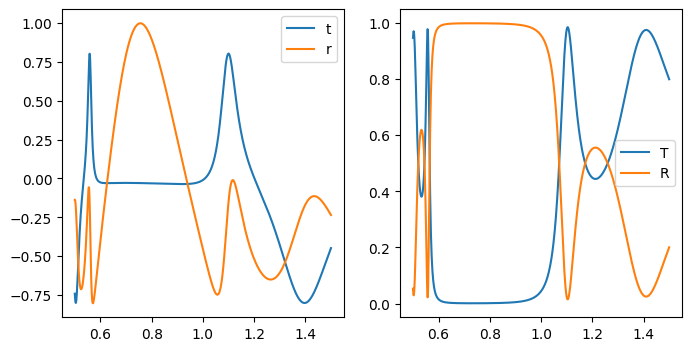

In [3]:
n_in = 1.
n_out = 1.5
angle_inc = 0
wavelength_vector = np.linspace(0.5, 1.5, 1001)
t, r, T, R = spectrum(thickness, epsilon, polarisation, wavelength_vector, angle_inc, n_in, n_out)
fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].plot(wavelength_vector, t.real, label='t')
ax[0].plot(wavelength_vector, r.real, label='r')
ax[0].legend()
ax[1].plot(wavelength_vector, T, label='T')
ax[1].plot(wavelength_vector, R, label='R')
plt.legend()

## Field Distribution in the Bragg Mirror

Visualise the electric field distribution inside the multilayer stack.
Left: absolute field amplitude $|f|$; Right: real part $\Re (f)$.

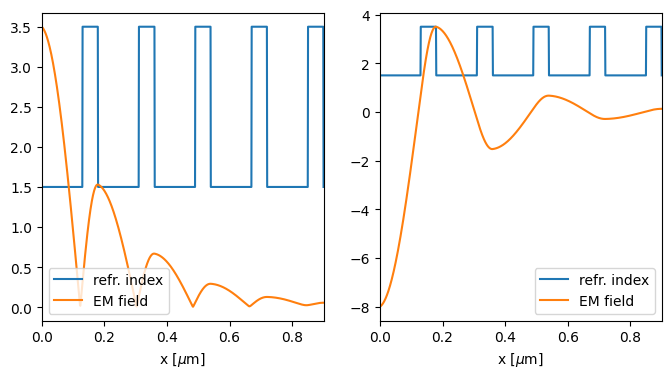

In [4]:
# field distribution
l_in = 0
l_out = 0
Nx = 1001
wavelength = 0.78
kz = 0
f, index, x = field(thickness, epsilon, polarisation, wavelength, kz, n_in ,n_out, Nx, l_in, l_out)
fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].plot(x, index.real, label='refr. index')
ax[0].plot(x, np.abs(f)/np.abs(f).real.max()*index.max(), label='EM field')
ax[0].legend()
ax[1].plot(x, index.real, label='refr. index')
ax[1].plot(x, f.real/f.real.max()*index.max(), label='EM field')
ax[1].legend()
for i in range(2):   
    ax[i].set_xlim(x[[0,-1]])
    ax[i].set_xlabel(r'x [$\mu$m]')

## Fabry-Perot Resonator

A Fabry-Perot cavity is formed by inserting a spacer layer between two Bragg mirrors.
The cavity introduces a transmission resonance within the stop band.

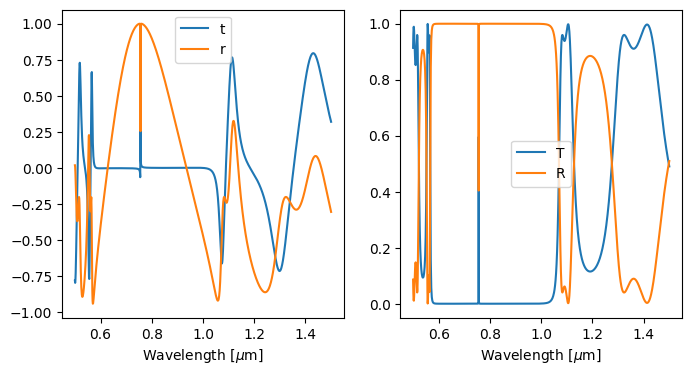

In [5]:
epsilon, thickness = bragg(n1, n2, d1, d2, N*2)
thickness[N*2] = 2*thickness[N*2]

t, r, T, R = spectrum(thickness, epsilon, polarisation, wavelength_vector, angle_inc, n_in, n_out)
fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].plot(wavelength_vector, t.real, label='t')
ax[0].plot(wavelength_vector, r.real, label='r')
ax[0].set_xlabel(r'Wavelength [$\mu$m]')
ax[0].legend()
ax[1].plot(wavelength_vector, T, label='T')
ax[1].plot(wavelength_vector, R, label='R')
ax[1].set_xlabel(r'Wavelength [$\mu$m]')
ax[1].legend()

## Field Distribution in the Fabry-Perot Cavity

The field is strongly enhanced inside the cavity spacer layer, characteristic of a resonant mode.
`l_in` and `l_out` extend the spatial output into the surrounding media for better visualisation.

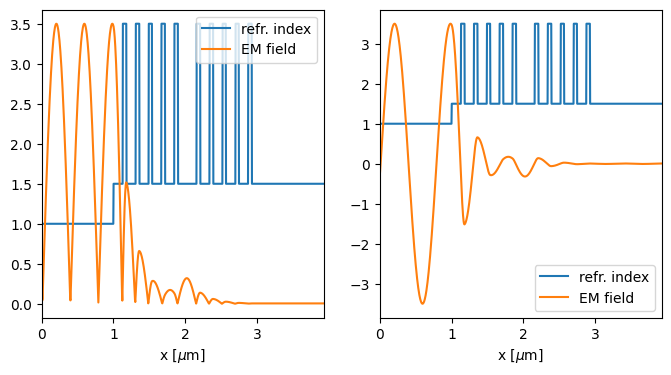

In [6]:
l_in = 1
l_out = 1
Nx = 1001
wavelength = 0.78
kz = 0
f, index, x = field(thickness, epsilon, polarisation, wavelength, kz, n_in ,n_out, Nx, l_in, l_out)
fig, ax = plt.subplots(1, 2, figsize = (8,4))
for i in range(2):   
    ax[i].set_xlim(x[[0,-1]])
    ax[i].set_xlabel(r'x [$\mu$m]')
ax[0].plot(x, index.real, label='refr. index')
ax[0].plot(x, np.abs(f)/np.abs(f).real.max()*index.max(), label='EM field')
ax[0].legend()
ax[1].plot(x, index.real, label='refr. index')
ax[1].plot(x, f.real/f.real.max()*index.max(), label='EM field')
ax[1].legend()

## Time-Domain Animation

Animate the time evolution of the real part of the field $\Re (f \times e^{-i\omega t})$ across the structure.
`steps` controls animation frames per period; `periods` sets the number of oscillation cycles shown.

MovieWriter ffmpeg unavailable; using Pillow instead.


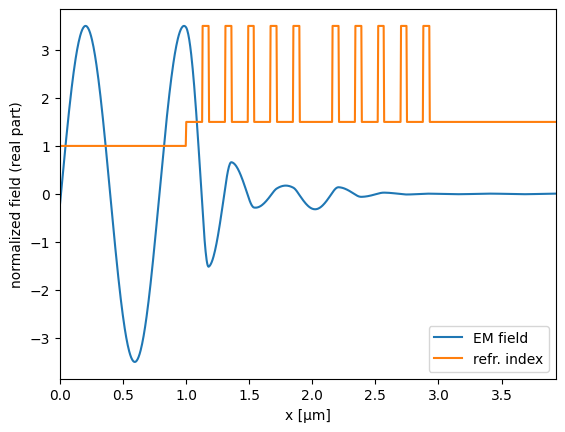

In [7]:
steps = 200
periods = 10
ani = time_animation(x, f, index, steps, periods)
ani.save("My animation.gif")